# Morris sensitivity Analysis (SALib)

In [1]:
import os
import sys
import logging
from tqdm import tqdm
import shutil
import json
from pathlib import Path

import ogstools as ot
import pyvista as pv
import pandas as pd
import numpy as np
from scipy import integrate
from SALib.sample import morris as morris_sampler
from SALib.analyze import morris as morris_analyzer

from meshing import create_rectangle_frac_mesh_v3
from functions_s import save_combined_mesh

In [2]:
#functions---------------------------------------

def run_simulation_OGS(prj_in, prj_out,factors,MESH_DIR,RUN_DIR,coords):
    try:
        temp_prj(prj_in, prj_out, factors)
        model = ot.Project(input_file=prj_out)
        model.run_model(args=f"-m {MESH_DIR} -o {RUN_DIR}", logfile="SA_log.txt")
        return extract_values(RUN_DIR, coords)
    except Exception as e:
        print(f"Simulation failed with params {factors}: {e}")
        return None 

def sens_index(result):

    if result is None or 'values' not in result or len(result['values']) == 0:
            return 0.0, 0.0, 0.0
        
    p = np.array(result['values'])
    t = np.array(result['timevalues'])
    
    sum_c = integrate.simpson(y=p, x=t) if len(p) > 1 else 0.0
    peak = np.max(p)
    p_end = p[-1]

    return sum_c, peak, p_end


def extract_values(RUN_DIR,coords): 

    pvd_files = list(Path(RUN_DIR).glob("*.pvd"))
    if not pvd_files:
        raise FileNotFoundError(f"No .pvd file found in {RUN_DIR}")
    
    pvd_path = pvd_files[0]
    ms = ot.MeshSeries(pvd_path)
    pressure=ot.variables.pressure
    pressure= pressure.replace(output_unit="MPa")
    
    ms_probes=ms.probe(points=coords)
    raw_pressure_array = ms_probes['pressure']
    clean_p = np.squeeze(raw_pressure_array) #or raw_pressure_array()[:,0] taking the one point scalar

    data_bundle = {
        'values': clean_p, 
        'timevalues': np.array(ms.timevalues),
        'metadata': {
            'variable_name': 'pressure',
            'unit': 'MPa',
            'time_unit': 's',
            'coordinates': coords,
            'source_file': str(pvd_path)
        }
    }

    return data_bundle



def Morris_sample(names,bounds,N=50,num_levels=4):

    problem = {'num_vars': len(names), 
            'names': names,
            'bounds': bounds}

    param_values = morris_sampler.sample(problem, N=N, num_levels=num_levels)

    return param_values


def calculate_keff(factors):
    pjack=factors['pjack']
    p1=factors['p1']
    p2=factors['p2']
    wr=max(factors['wr'], 1e-6)
    k01=factors['k01']
    k02=factors['k02']

    prev=np.linspace(p1,p2,50)

    tanh_term = np.tanh((prev - pjack) / wr)
    c=(k02 - k01) * 0.5
    k_value = k01 + c* (1 + tanh_term)

    sf0=factors['sf0']
    beta_dimen=factors['b_dim']
    beta=pjack*beta_dimen

    X= np.sqrt(3)*np.sqrt(k_value)/k_value
    Y= c*(1-tanh_term**2)/wr
    s_value=  sf0 + beta*X*Y

    keff=k_value*s_value/sf0
    return keff


def temp_prj(prj_in, prj_out,factors): 

    keff=factors['keff']
    kmatrix=factors['k01'] #considering kma=k01, kfrac and kma start from same basis
    smatrix=factors['sma']

    values_str = " ".join(map(str, keff))

    model = ot.Project(input_file=prj_in,output_file=prj_out)
    xpath='./curves/curve[name="k_curve"]/values'
    medium=0

    try:
        model.replace_text(values_str,xpath)
        model.replace_medium_property_value(medium,'permeability',kmatrix) 
        model.replace_medium_property_value(medium,'storage',smatrix)

    except Exception as e:
        print(f"CRITICAL ERROR in PRJ update: {e}")
        raise # Stop the loop if the input file is not correctly updated

    model.write_input()



In [3]:
#pre-conditions-------------------------------------------

OGS_PATH = r"D:\OGS_Executable\ogs-6.5.7-Windows-10.0.26200-python-3.13.7-utils\bin"

if OGS_PATH is not None:
    os.environ["OGS_BIN_PATH"] = OGS_PATH
OUT_DIR = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out_t"))
MESH_DIR = OUT_DIR / "mesh"
RUN_DIR=OUT_DIR / "run"
RESULTS_DIR = OUT_DIR / "results"
npy_dir = RESULTS_DIR / "raw_data"



shutil.rmtree(OUT_DIR, ignore_errors=True)
MESH_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
npy_dir.mkdir(parents=True, exist_ok=True)

logging.basicConfig(
    filename='simulation_run.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

tqdm.monitor_interval = 0 #hide OGS probes loading bar

cwd=Path.cwd()
prj_in=cwd/'BH10_20180718_40.6_SA.prj'
prj_out=cwd/'_out_t/BH10_20180718_40.6_SA_temp.prj'

factors={
         'k01':1.0,
         'k02':1.0,
         'sma':1.0,
         'pjack':1.0,
         'wr':1.0,
         'b_dim':1.0,
         'sf0':8.5e-4,
         'p1':1.0,
         'p2':5.0e6,
         'keff':1.0
}

y=-40.6
r_st=0.038 
coords = np.array([[r_st, y, 1e-18]])
labels= f"OGS: r={r_st:>5.3f}, y={y}" 

names=list(factors.keys())
names=names[:-4]
bounds=[[1.0e-15,3e-15],
                        [1.0e-11,1e-7],
                        [2.0e-11,2e-9],
                        [3.1e6,3.6e6],
                        [0.2e6,0.5e6],
                        [1.0,5.0],
                        ]

MSH_FILE = MESH_DIR / "symmetric_cylinder_2D.msh"
h=0.7 #mesh as in field data
r_well=0.038
thickness=h
mesh_size=thickness/4
refine_well=thickness/20 #thickness/20
refine_frac=thickness/30 #thickness/30 #smaller than well refinining

create_rectangle_frac_mesh_v3(
    MSH_FILE,
    radius= 100,
    height= thickness,
    mesh_size= mesh_size,
    center_z=-40.6,
    r_well = r_well,
    length = 8,
    refine_well = refine_well,  # Element size at the well
    refine_frac = refine_frac   # Element size along the fracture
) 


meshes = ot.Meshes.from_gmsh(MSH_FILE, log=False)
for name, mesh in meshes.items():
    vtu_path = (MESH_DIR / f"rectangle_{name}.vtu").as_posix()
    pv.save_meshio(vtu_path, mesh)
    print(f"Saved {vtu_path}")

combined_vtu = (MESH_DIR / "combined_fracture_mesh.vtu").as_posix()
save_combined_mesh(MSH_FILE, combined_vtu)



CMD: D:\OGS_Executable\ogs-6.5.7-Windows-10.0.26200-python-3.13.7-utils\bin\NodeReordering
Saved _out_t/mesh/rectangle_domain.vtu
Saved _out_t/mesh/rectangle_intersection_point.vtu
Saved _out_t/mesh/rectangle_fracture_tip.vtu
Saved _out_t/mesh/rectangle_well.vtu
Saved _out_t/mesh/rectangle_fracture.vtu
Saved _out_t/mesh/rectangle_top.vtu
Saved _out_t/mesh/rectangle_bottom.vtu
Saved _out_t/mesh/rectangle_boundary_R.vtu
Saved _out_t/mesh/rectangle_bulk_mesh.vtu

Combined mesh saved to: _out_t/mesh/combined_fracture_mesh.vtu


In [4]:
#generating the sampling and loading/updating register and factors

version = "v3" 
filename = f"morris_samples_{version}.csv"
archive_file = RESULTS_DIR / f"results_archive_{version}.jsonl"

if not os.path.exists(filename):
    X = Morris_sample(names, bounds, N=20, num_levels=4)
    pd.DataFrame(X, columns=names).to_csv(filename, index=False)

    with open(archive_file, "w") as f:
        pass 
    print(f"Created new archive: {archive_file}")

if not os.path.exists(archive_file):
    with open(archive_file, "w") as f:
        pass # Creates an empty file
    print(f"Initialized empty archive: {archive_file}")

df_X = pd.read_csv(filename)
archive_file = archive_file

processed_indices = set()
with open(archive_file, "r") as f:
    for line in f:
        try:
            entry = json.loads(line)
            processed_indices.add(entry["index"])
        except json.JSONDecodeError:
            continue 

static_factors = {'sf0': 8.5e-4, 'p1': 1.0, 'p2': 5.0e6, 'keff':1.0}

df_full = df_X.copy()
for key, value in static_factors.items():
    df_full[key] = value

Created new archive: _out_t\results\results_archive_v3.jsonl


In [ ]:
#exectution of OGS-morris: sensitivity indexes and binary results


for i in tqdm(range(len(df_full)), desc="Overall Progress", unit="run"):
    if i in processed_indices:
        continue
    
    factors = df_full.iloc[i].to_dict()
    factors['keff'] = calculate_keff(factors)
    
    if RUN_DIR.exists(): shutil.rmtree(RUN_DIR)
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    

    try:
        result = run_simulation_OGS(prj_in, prj_out, factors, MESH_DIR, RUN_DIR, coords)
        
        if result is not None:
            np.save(npy_dir / f"raw_run_{i}.npy", result) #binary saving per run
            sum_c, peak, p_end = sens_index(result)
            
            logging.info(f"Run {i} successful | Peak={peak:.2e}")
        else:
            logging.warning(f"Run {i} returned None (Simulation Failure)")
            sum_c, peak, p_end = 0.0, 0.0, 0.0

        with open(archive_file, "a") as f:
            f.write(json.dumps({"index": i, "sum_c": sum_c, "peak": peak, "p_end": p_end}) + "\n")
            
    except Exception as e:
        logging.error(f"Run {i} crashed: {str(e)}")
        continue 

Overall Progress:   0%|          | 0/140 [00:00<?, ?run/s]

Overall Progress: 100%|██████████| 140/140 [2:07:50<00:00, 54.79s/run]


In [6]:

#arch=np.load(Path.cwd()/'_out_t/results/raw_data/raw_run_13.npy',allow_pickle=True).item()

In [7]:
# import matplotlib.pyplot as plt
# plt.plot(arch['timevalues'],arch['values'])

# Analysis

In [2]:
#analysis
names=['k01',	'k02',	'sma',	'pjack',	'wr',	'b_dim']
bounds=[[1.0e-15,3e-15],
                        [1.0e-11,1e-7],
                        [2.0e-11,2e-9],
                        [3.1e6,3.6e6],
                        [0.2e6,0.5e6],
                        [1.0,5.0]
                        ]
problem = {'num_vars': len(names), 
        'names': names,
        'bounds': bounds}

def load_jdata(jsonl_file):
    with open(jsonl_file, 'r') as f:
        data = [json.loads(line) for line in f]
    return data

def get_metric_array(data, metric_key):
    data.sort(key=lambda x: x['index'])
    return np.array([item[metric_key] for item in data])

In [15]:
version='v4'
json_file=Path.cwd()/f'results_{version}/results/results_archive_{version}.jsonl'
sample_archive=Path.cwd()/f'results_{version}/morris_samples_{version}.csv'


Y_a = load_jdata(json_file)
X_a = pd.read_csv(sample_archive).values 

metrics = ['sum_c', 'peak', 'p_end']
results4 = {}

for m in metrics:
    Ym = get_metric_array(Y_a, m)
    
    Si = morris_analyzer.analyze(problem, X_a, Ym, num_levels=4)
    results4[m] = Si
    
    # # Output check
    # print(f"Results for {m}: {Si['mu_star']}")


In [16]:
import matplotlib.pyplot as plt
# for i, metrics in results:

plt.scatter(results['sum_c']['names'],results['sum_c']['mu_star'], label=f'$\mu*$')
plt.legend()
plt.pause(1)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\acer\AppData\Local\Temp\ipykernel_26816\1177611586.py:4: SyntaxWarning: invalid escape sequence '\m'
  plt.scatter(results['sum_c']['names'],results['sum_c']['mu_star'], label=f'$\mu*$')


KeyError: 'sum_c'

In [ ]:
N_list=[2,10,15,20]
results=[results1,results2,results3,results4]

In [120]:
bounds[0       ][1]

3e-15

In [121]:
scaling_bounds=[]
for i in range(len(bounds)):
    scal=bounds[i][1]-bounds[i][0]
    scaling_bounds.append(scal)

In [127]:
for i in range(len(results)):
    for j in range(len(results[0]['sum_c']['mu_star'])):
        results[i]['sum_c']['mu_star'][j]=results[i]['sum_c']['mu_star'][j]*scaling_bounds[j]
        results[i]['sum_c']['sigma'][j]=results[i]['sum_c']['sigma'][j]*scaling_bounds[j]

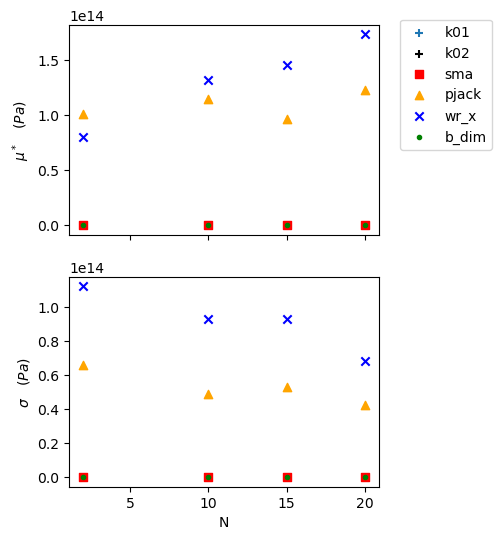

In [133]:
fig0, axs= plt.subplots(nrows=2,ncols=1,figsize=[4,6],sharex=True)
labels = ["k01", "k02", "sma", "pjack", "wr_x", "b_dim"]

for i in range(0,4):
    is_first = i == 0

    axs[0].scatter(N_list[i],results[i]['sum_c']['mu_star'][0],color='tab:blue',marker='+', label=labels[0] if is_first else "") #k01
    axs[0].scatter(N_list[i],results[i]['sum_c']['mu_star'][1],color='k',marker='+',        label=labels[1] if is_first else "") #k02
    axs[0].scatter(N_list[i],results[i]['sum_c']['mu_star'][2],color='red',marker='s',      label=labels[2] if is_first else "") #sma
    axs[0].scatter(N_list[i],results[i]['sum_c']['mu_star'][3],color='orange',marker='^',   label=labels[3] if is_first else "") #pjack
    axs[0].scatter(N_list[i],results[i]['sum_c']['mu_star'][4],color='blue',marker='x',     label=labels[4] if is_first else "") #wr
    axs[0].scatter(N_list[i],results[i]['sum_c']['mu_star'][5],color='green',marker='.',    label=labels[5] if is_first else "") #b_dim

    axs[1].scatter(N_list[i],results[i]['sum_c']['sigma'][0],color='tab:blue',marker='+') #k01
    axs[1].scatter(N_list[i],results[i]['sum_c']['sigma'][1],color='k',marker='+') #k02
    axs[1].scatter(N_list[i],results[i]['sum_c']['sigma'][2],color='red',marker='s') #sma
    axs[1].scatter(N_list[i],results[i]['sum_c']['sigma'][3],color='orange',marker='^') #pjack
    axs[1].scatter(N_list[i],results[i]['sum_c']['sigma'][4],color='blue',marker='x') #wr
    axs[1].scatter(N_list[i],results[i]['sum_c']['sigma'][5],color='green',marker='.') #b_dim

axs[0].set_ylabel(r'$\mu^* \quad (Pa)$')
axs[1].set_ylabel(r'$\sigma \quad (Pa)$')
axs[1].set_xlabel("N")

handles, leg_labels = axs[0].get_legend_handles_labels()
fig0.legend(handles, leg_labels, loc='upper right', bbox_to_anchor=(1.2, 0.9))
plt.show()

In [105]:
results[1]['sum_c']

{'names': array(['k01', 'k02', 'sma', 'pjack', 'wr', 'b_dim'], dtype='<U5'),
 'mu': masked_array(data=[-633188747.1531767, -2373922344.0186934,
                    -134890814.11641198, 228532648.58332568,
                    -438517880.0450827, -33247492.732150055],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'mu_star': masked_array(data=[633188747.1531767, 2373922344.0186934,
                    134890814.11641198, 228532648.58332568,
                    438517880.0450827, 33247492.732150055],
              mask=[False, False, False, False, False, False],
        fill_value=1e+20),
 'sigma': array([6.66517068e+08, 1.28646663e+09, 1.50181037e+08, 9.76176030e+07,
        3.10396349e+08, 2.59235213e+07]),
 'mu_star_conf': masked_array(data=[366940558.29362565, 748238147.138879,
                    91806824.30044264, 54816034.1197971,
                    197450868.86801744, 16992787.063341737],
              mask=[False, False, False, False, 

In [84]:
N_list[1]

10